# Neptune Analytics 그래프 탐색

Neptune Analytics 그래프를 Jupyter notebook에서 탐색하고 시각화합니다.

## 1. 설정 및 연결

In [1]:
# 필요한 라이브러리 임포트
import sys
import os

# 현재 디렉토리를 경로에 추가
# 작업 디렉토리 변경
os.chdir('/home/ec2-user/strandtest/moive')
print(f"📂 현재 디렉토리: {os.getcwd()}")

# 경로 추가
sys.path.insert(0, '/home/ec2-user/strandtest/moive')

from tool import get_neptune_client
import json
import pandas as pd

# Neptune 클라이언트 생성
neptune = get_neptune_client()

print("✅ Neptune 연결 완료")

📂 현재 디렉토리: /home/ec2-user/strandtest/moive
✅ Neptune 연결 준비 완료
   Graph ID: g-z8n5so6q32
   Region: us-east-1
✅ Neptune 연결 완료


## 2. 그래프 통계

In [2]:
# 전체 통계
stats = neptune.get_stats()

print(f"📊 그래프 통계")
print(f"총 노드: {stats['total_nodes']}")
print(f"총 관계: {stats['total_relationships']}")
print(f"\n노드 레이블:")
for label, count in stats['node_labels'].items():
    print(f"  - {label}: {count}개")

📊 그래프 통계
총 노드: 256677
총 관계: 784727

노드 레이블:
  - Movie: 45433개
  - ProductionCompany: 23692개
  - Person: 187239개
  - SpokenLanguage: 133개
  - Country: 160개
  - Genre: 20개


## 3. 커스텀 쿼리 실행

In [3]:
# openCypher 쿼리 실행 함수
def query(cypher_query, params=None):
    """쿼리 실행 및 결과를 DataFrame으로 반환"""
    result = neptune.execute_query(cypher_query, params)
    results = result.get('results', [])
    
    if results:
        return pd.DataFrame(results)
    else:
        return pd.DataFrame()

# 예제: 모든 노드 조회 (최대 10개)
df = query("MATCH (n) RETURN n LIMIT 10")
df

,n
0,{'~id': 'd42b848f-c7eb-4282-a897-dbe8ae08dfc71...
1,{'~id': 'ecda6e99-10fa-4ae1-8984-af0fdd3f0ea09...
2,{'~id': '34d28c72-3835-4337-aa48-f09fb9c8f8cf4...
3,{'~id': '34d28c72-3835-4337-aa48-f09fb9c8f8cf1...
4,{'~id': '34d28c72-3835-4337-aa48-f09fb9c8f8cf7...
5,{'~id': '981b5070-2193-4f7a-9c87-915cf4f5d3186...
6,{'~id': '981b5070-2193-4f7a-9c87-915cf4f5d3182...
7,{'~id': '241d4eb1-2e45-4d14-b958-32850851e7d13...
8,{'~id': '36f762d6-7391-42d6-af8a-b98abfe361f64...
9,{'~id': '36f762d6-7391-42d6-af8a-b98abfe361f61...


In [4]:
import networkx as nx
import matplotlib.pyplot as plt

In [6]:
# 관계 데이터 가져오기
def visualize_movie_genre():
    edges_df = query("""
    MATCH (m:Movie)-[:HAS_GENRE]->(g:Genre)
    RETURN m.title as movie, g.genre_name as genre
    LIMIT 50
    """)
    
    G = nx.from_pandas_edgelist(edges_df, source='movie', target='genre')
    
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=2, iterations=50)
    
    # 노드 색상 구분 (영화 vs 장르)
    node_colors = ['lightblue' if node in edges_df['movie'].values else 'lightgreen' 
                   for node in G.nodes()]
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=1000, font_size=8, font_weight='bold')
    plt.title("Movie-Genre Relationships")
    plt.show()

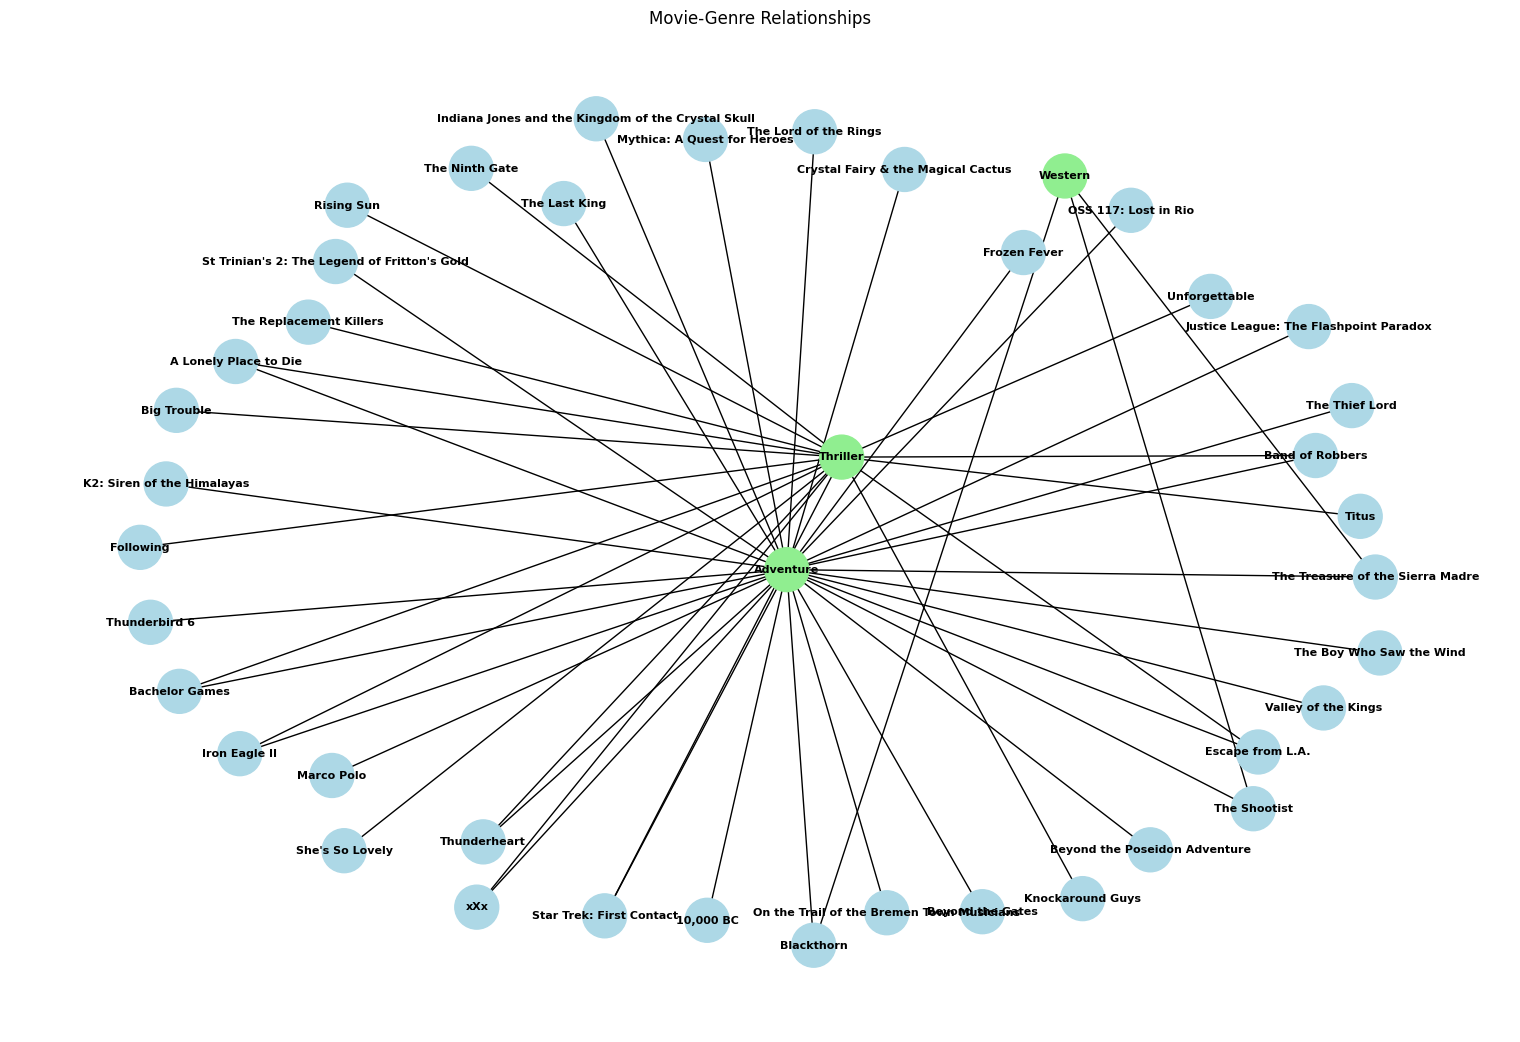

In [7]:
visualize_movie_genre()

In [8]:
def visualize_actor_movie():
    edges_df = query("""
    MATCH (a:Actor)-[:ACTED_IN]->(m:Movie)
    RETURN a.name as actor, m.title as movie
    LIMIT 30
    """)
    
    G = nx.from_pandas_edgelist(edges_df, source='actor', target='movie')
    
    plt.figure(figsize=(15, 10))
    pos = nx.spring_layout(G, k=3, iterations=50)
    
    node_colors = ['orange' if node in edges_df['actor'].values else 'lightblue' 
                   for node in G.nodes()]
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=1200, font_size=7, font_weight='bold')
    plt.title("Actor-Movie Relationships")
    plt.show()

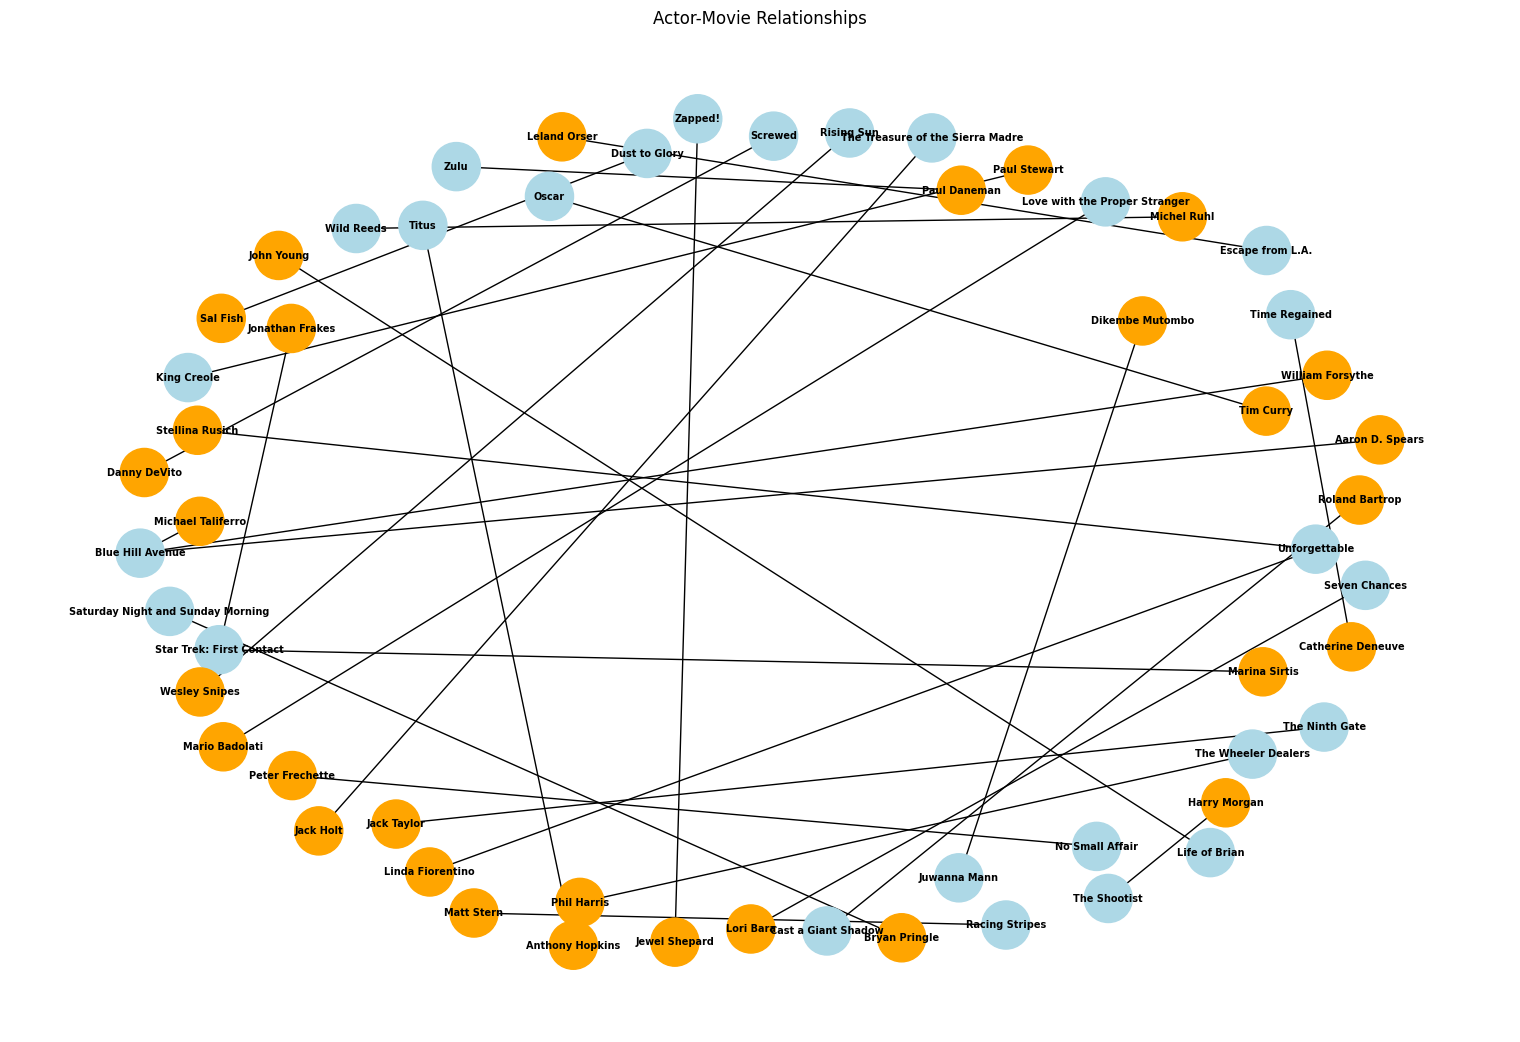

In [9]:
visualize_actor_movie()

In [14]:
# 3. 감독-영화 관계
def plot_director_movie():
    edges_df = query("""
    MATCH (d:Director)-[:DIRECTED]->(m:Movie)
    RETURN d.name as director, m.title as movie
    LIMIT 25
    """)
    
    G = nx.from_pandas_edgelist(edges_df, source='director', target='movie')
    
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2)
    
    # 감독은 빨간색, 영화는 파란색
    node_colors = ['red' if node in edges_df['director'].values else 'lightblue' 
                   for node in G.nodes()]
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=1000, font_size=7, font_weight='bold')
    plt.title("3. Director-Movie Relationships")
    plt.tight_layout()
    plt.show()
# 더 간단한 버전

/tmp/ipykernel_3146699/1958183918.py:21: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


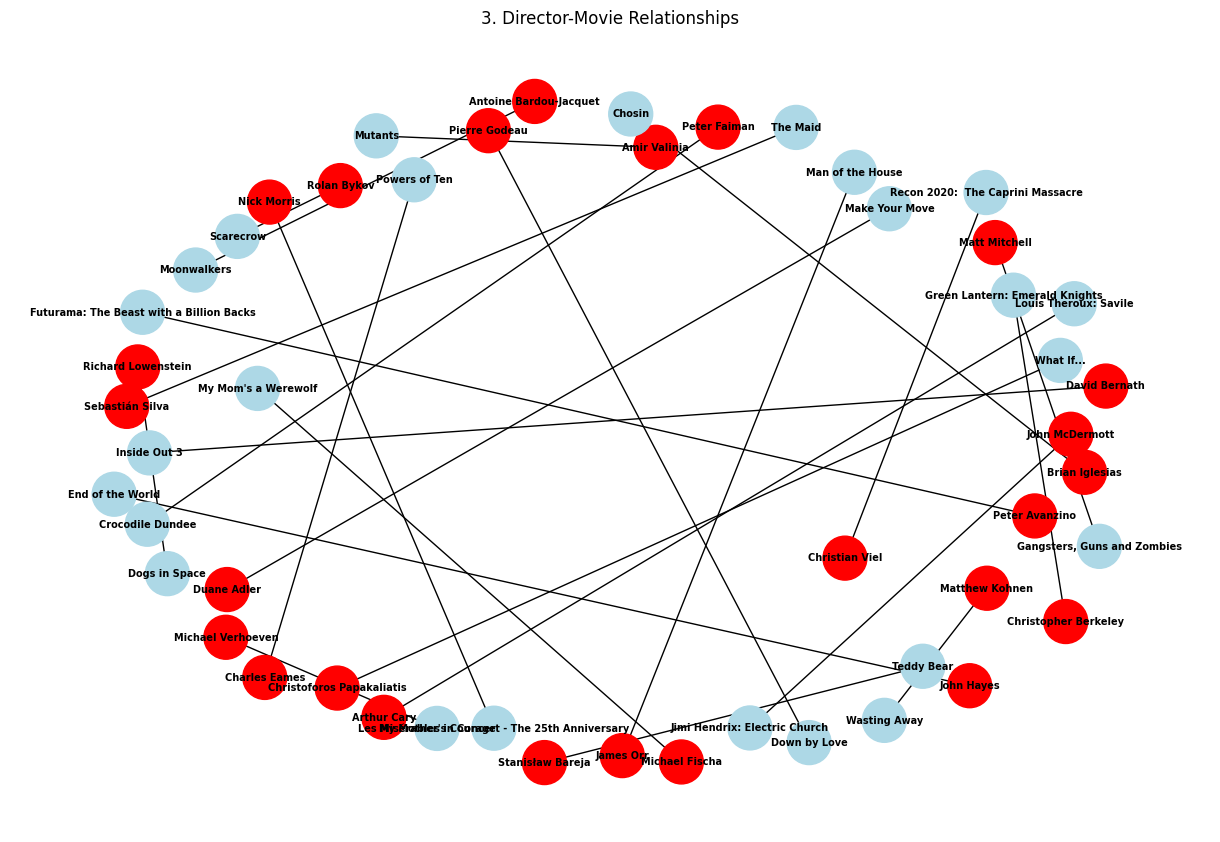

In [15]:
plot_director_movie()

In [16]:
def plot_movie_company():
    edges_df = query("""
    MATCH (m:Movie)-[:PRODUCED_BY]->(c:ProductionCompany)
    RETURN m.title as movie, c.company_name as company
    LIMIT 35
    """)
    
    G = nx.from_pandas_edgelist(edges_df, source='movie', target='company')
    
    plt.figure(figsize=(12, 8))
    pos = nx.spring_layout(G, k=2)
    
    # 영화는 파란색, 제작사는 보라색
    node_colors = ['lightblue' if node in edges_df['movie'].values else 'plum' 
                   for node in G.nodes()]
    
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=1000, font_size=7, font_weight='bold')
    plt.title("4. Movie-Production Company Relationships")
    plt.tight_layout()
    plt.show()

/tmp/ipykernel_3146699/2387884150.py:20: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


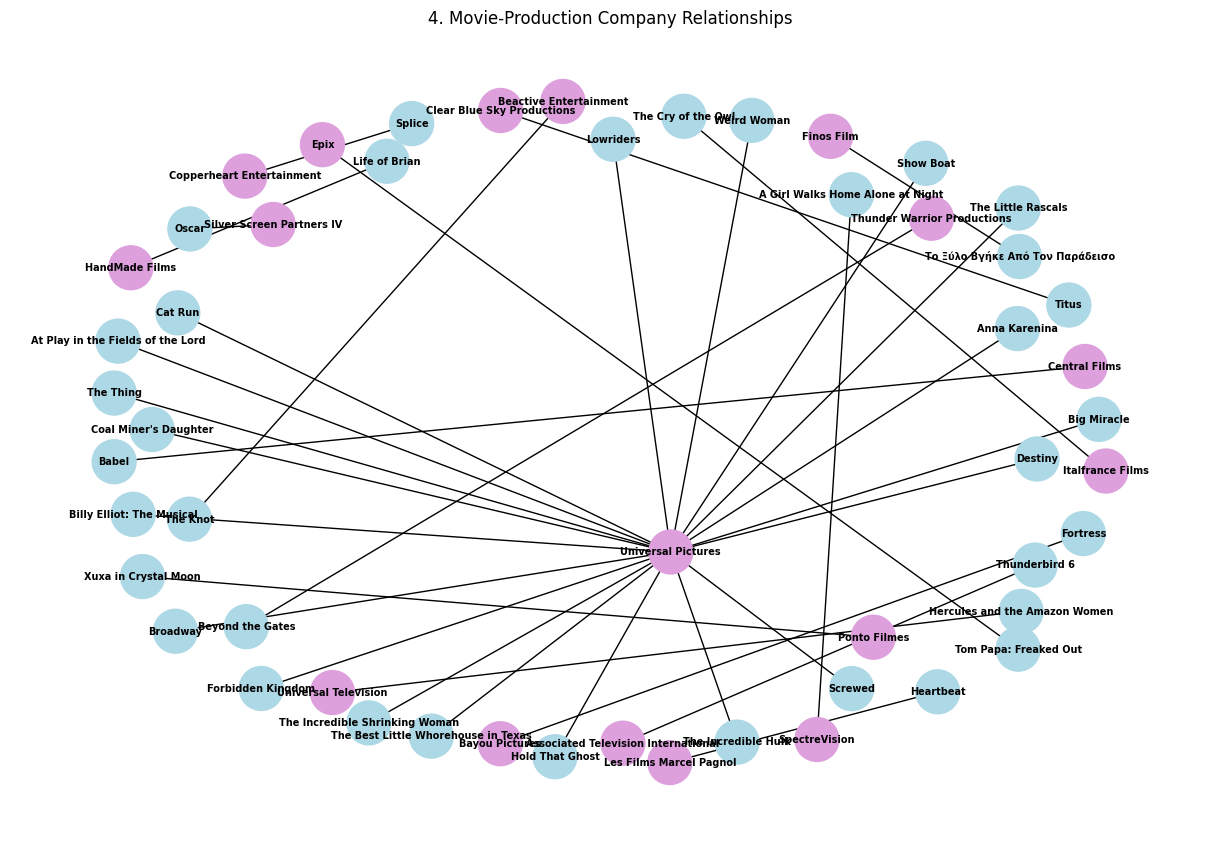

In [17]:
plot_movie_company()

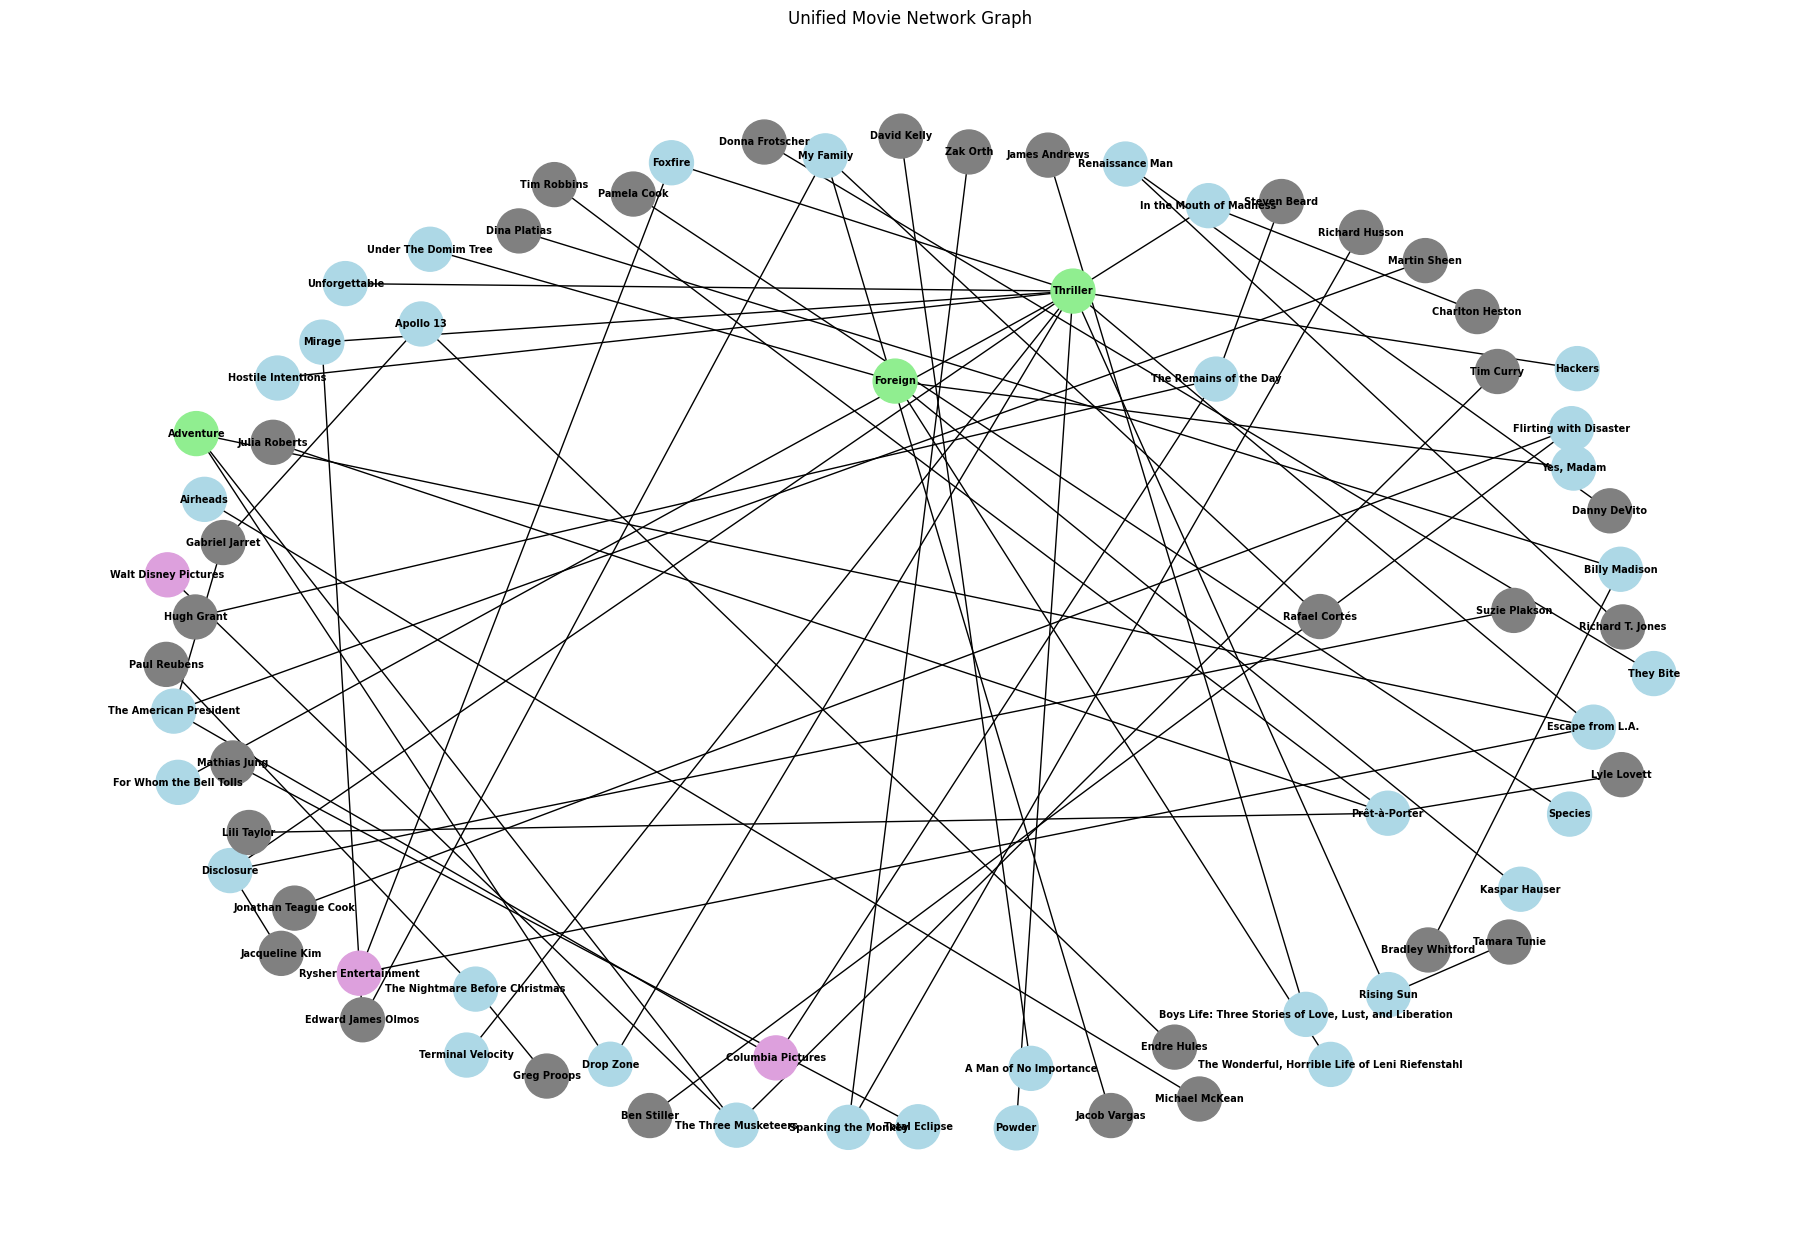

In [18]:
def plot_unified_graph():
    # 모든 관계를 한번에 조회
    all_data = query("""
    MATCH (n)-[r]->(m)
    WHERE (n:Movie OR n:Actor OR n:Director) AND 
          (m:Movie OR m:Genre OR m:ProductionCompany)
    RETURN 
        CASE 
            WHEN 'Movie' IN labels(n) THEN n.title
            WHEN 'Actor' IN labels(n) THEN n.name
            WHEN 'Director' IN labels(n) THEN n.name
        END as source,
        CASE 
            WHEN 'Movie' IN labels(m) THEN m.title
            WHEN 'Genre' IN labels(m) THEN m.genre_name
            WHEN 'ProductionCompany' IN labels(m) THEN m.company_name
        END as target,
        labels(n)[0] as source_type,
        labels(m)[0] as target_type
    LIMIT 60
    """)
    
    G = nx.from_pandas_edgelist(all_data, source='source', target='target')
    
    # 노드별 색상 지정
    color_map = {'Movie': 'lightblue', 'Actor': 'orange', 'Director': 'red', 
                 'Genre': 'lightgreen', 'ProductionCompany': 'plum'}
    
    node_colors = []
    for node in G.nodes():
        # 노드 타입 찾기
        node_type = None
        for _, row in all_data.iterrows():
            if row['source'] == node:
                node_type = row['source_type']
                break
            elif row['target'] == node:
                node_type = row['target_type']
                break
        node_colors.append(color_map.get(node_type, 'gray'))
    
    plt.figure(figsize=(18, 12))
    pos = nx.spring_layout(G, k=2, iterations=50)
    nx.draw(G, pos, with_labels=True, node_color=node_colors, 
            node_size=1000, font_size=7, font_weight='bold')
    plt.title("Unified Movie Network Graph")
    plt.show()

plot_unified_graph()